In [1]:
import pandas as pd

import pickle

from tqdm.notebook import tqdm

import os
from dotenv import load_dotenv

from IPython.display import display, Markdown

from langchain_openai import ChatOpenAI

import json

import numpy as np

import concurrent.futures
import logging

from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import LabelEncoder

import seaborn as sns # Optional: for a visual heatmap
import matplotlib.pyplot as plt # Optional: for plotting

from adr import adr
import utils
from adr_classification import ADRClassifier, ClassificationFramework
from adr_classification import ZimmermannEnum, KruchtenEnum, QualityAttributesEnum


---

In [2]:

ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle'

# logging.basicConfig(stream=sys.stdout, level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

print(load_dotenv())

# os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
# os.environ["OPENAI_MODEL_NAME"] = 'gpt-4o-mini'
print(os.environ["OPENAI_MODEL_NAME"])

True
gpt-4.1-nano


In [3]:
# Datasets with examples manually tagged by humans
ZIMMERMANN_GROUND_TRUTH = './sample/zimmermann_gt_processed1.csv'

# Datasets of examples for few-shot strategy
ZIMMERMANN_FEW_SHOTS = '../sample/zimmermann_fewshots_raw.json'

---

### Load the Dataset of ADRs

In [4]:
# Configure LLM via Langchain
llm = ChatOpenAI(
      model=os.environ["OPENAI_MODEL_NAME"], temperature=0.0, 
      # callback_manager=CallbackManager([StreamingStdOutCallbackHandler()])
)
# llm.invoke("Tell me a joke about data scientists")

In [5]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(valid_projects, dict_adrs, field='raw')
print(len(docs), "ADRs considered within valid projects")

547 projects/organizations?


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

4316 ADRs considered within valid projects


In [6]:
# Select a sample set of ADRs to classify
adrs_to_classify = utils.get_documents_by_key(('LBHackney-IT', 'remultiform'), dict_adrs, field='raw')
adrs_to_classify

{'0001-record-architecture-decisions.md': "# 1. Record architecture decisions\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe need to record the architectural decisions made on this project.\n\n## Decision\n\nWe will use Architecture Decision Records, as\n[described by Michael Nygard](http://thinkrelevance.com/blog/2011/11/15/documenting-architecture-decisions).\n\n## Consequences\n\nSee Michael Nygard's article, linked above. For a lightweight ADR toolset, see\nNat Pryce's [adr-tools](https://github.com/npryce/adr-tools).\n",
 '0002-use-typescript.md': "# 2. Use TypeScript\n\nDate: 2019-10-29\n\n## Status\n\nAccepted\n\n## Context\n\nWe want to be confident about the code we write, and for it to be\nself-documenting as much as possible.\n[TypeScript](https://www.typescriptlang.org/) is a compiled language with\noptional typing. It's a superset of JavaScript, so is familiar to developers who\nknow JavaScript. It has wide editor support.\n\nAs of writing, TypeScript is 

---

### 1. Quality Attribute Framework

In [7]:
# Load ground truth
relative_path = os.path.join('..', ZIMMERMANN_GROUND_TRUTH)
df_gt = pd.read_csv(relative_path, sep=';').dropna(subset=['text', 'human', 'ADR', 'raw_text'])
print(df_gt.shape)

# Print the categories (4) covered by the ground truth
print(len(df_gt['human'].unique()), df_gt['human'].unique())
print(len(df_gt['primary_category'].unique()), df_gt['primary_category'].unique())

adr_texts = {row['ADR']: row['raw_text'] for _, row in df_gt.iterrows()}
df_gt.head()

# Note: There's no Quality Attribute in ground truth?

(200, 9)
8 ['Design' 'Infrastructure' 'Technology' 'Implementation'
 'Crosscutting Concerns' 'Constraint' 'Organizational/Process' 'Other']
8 ['Design' 'Infrastructure' 'Technology' 'Constraint' 'Other'
 'Crosscutting Concerns' 'Implementation' 'Organizational/Process']


,text,ADR,Organization-Project,primary_category,explanation,max_confidence_value,human,Agreement,raw_text
0,'adr 3: connecting the store to a component pw...,adr-003-store-connector-container-component.md,"('AYCHAIN', 'AYCHAIN.github.io')",Design,The ADR primarily discusses the architectural ...,"0,85",Design,1.0,# ADR 3: Connecting the store to a component\n...
1,'4. compute provisioning through ansible Accep...,adr-004.md,"('Abelaa', 'pcmt')",Infrastructure,The ADR focuses on provisioning and deployment...,"0,70",Infrastructure,1.0,# 4. Compute Provisioning through Ansible\n\n#...
2,"'7. versioning and release mechanism Accepted,...",adr-007.md,"('Abelaa', 'pcmt')",Technology,The ADR focuses on establishing a versioning a...,"0,75",Technology,1.0,# 7. Versioning and Release Mechanism\n\n## St...
3,"'3. for config, prefer prefix over nesting and...",0003-for-config-prefer-prefix-over-nesting-and...,"('Accenture', 'reactive-interaction-gateway')",Design,The ADR primarily addresses the organization a...,"0,85",Infrastructure,0.0,"# 3. For config, prefer prefix over nesting an..."
4,'cutting release branch does not create a set ...,005-cutting-release-branch.md,"('Accenture', 'sfpowerscripts')",Technology,The ADR primarily discusses changes to the rel...,"0,60",Technology,1.0,# Cutting release branch does not create a set...


In [8]:
labels = sorted([str(member.value) for member in ZimmermannEnum])
print(len(labels), labels)

# Encoding target
# le = LabelEncoder()
# encoding = le.fit_transform(labels)

9 ['Constraint', 'Crosscutting Concerns', 'Design', 'Implementation', 'Infrastructure', 'Organizational/Process', 'Other', 'Quality Attribute', 'Technology']


In [9]:
# Get a particular (random) ADR from the ground truth to test classification
adr_example = df_gt['raw_text'].tolist()[8]
# adr_example = list(adr_texts.values())[8]
adr_example

"# Web Application\n\n**Status:** Accepted\n\n## Context\n\nWe need an application platform that meets the following requirements:\n\n- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.\n- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.\n\n### Option 1 - Cache First Web App (PWA)\n\nBy creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.\n\n### Option 2 - Native application\n\nAnother option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed m

#### Zero-shot Strategy

In [10]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.ZIMMERMANN, include_examples=False)

{"asctime": "2026-01-05 23:38:02,492", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: zimmermann, include_examples=False"}


In [11]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one primary category. 
Use the category definitions, guidelines and rules provided below.

## Categories:
- **Design**: This decision concerns the logical organization, structure, and decomposition of the system. It is related to patterns, components, layering, interfaces, data modeling.
- **Technology**: This decision concerns the selection of technologies, platforms, frameworks, libraries, or standards.
- **Infrastructure**: This decision involves the deployment environment, hosting, runtime platforms, networking, and hardware concerns.
- **Organizational/Process**: This decision concerns team structures, roles, responsibilities, workflows, and processes that affect architecture.
- **Constraint**: It refers to mandatory conditions from the business, regulations, or existing systems that limit architectural choices.
- **Quality Attribute**: This decis

In [12]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-05 23:38:02,627", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "zimmermann",
    "primary_category": "Design",
    "explanation": "The ADR primarily concerns the choice of creating a web application with offline capabilities, which relates to the system's structure and how it is organized to meet functional requirements. It discusses the architecture of the app, including its offline behavior, caching strategies, and platform compatibility, all of which are aspects of system design.",
    "primary_score": 0.85,
    "alternative_categories": [
        "Technology"
    ],
    "alternative_confidence_scores": [
        0.15
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)


In [13]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_zero_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/zimmermann_gt_processed1_zero_shot_results.json
Evaluating on ground truth with 200 ADRs.
Saving results to JSON file (for later processing) .././sample/zimmermann_gt_processed1_zero_shot_results.json


In [14]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=9)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=9)

{"asctime": "2026-01-05 23:38:21,075", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}
{"asctime": "2026-01-05 23:38:21,076", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}
{"asctime": "2026-01-05 23:38:21,076", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}
{"asctime": "2026-01-05 23:38:21,077", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric

In [15]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Design', 'Implementation', 'Other', 'Organizational/Process', 'Infrastructure', 'Quality Attribute', 'Constraint', 'Technology', 'Crosscutting Concerns']

Matthews Coefficient: 0.26619682645147597
Similarities with GT (%): 48.0
Kappa agreement with GT: 0.24955803297615176


{'Constraint': -0.006711409395973256,
 'Crosscutting Concerns': 0.20993227990970653,
 'Design': 0.21718377088305485,
 'Implementation': 0.0,
 'Infrastructure': 0.2727272727272727,
 'Organizational/Process': 0.5871559633027523,
 'Other': -0.019108280254777066,
 'Quality Attribute': 0.0,
 'Technology': 0.3306891422905306}

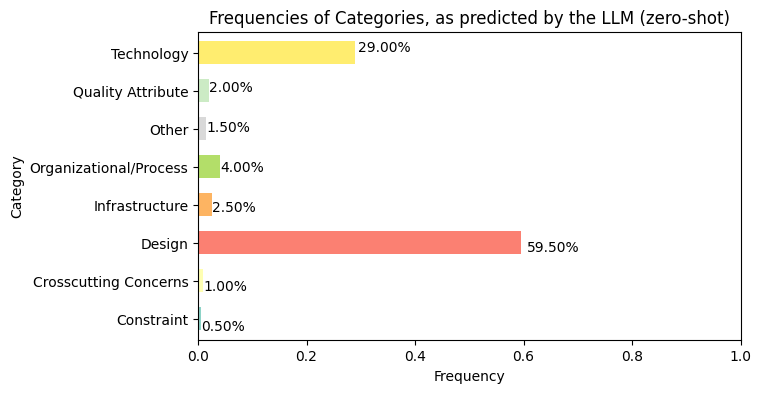

In [16]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (zero-shot)"
_ = utils.show_target_frequencies(pd.Series(target_values), title=title) #, encoding=encoding)

# Note: Compatibility is missing in the LLM predictions

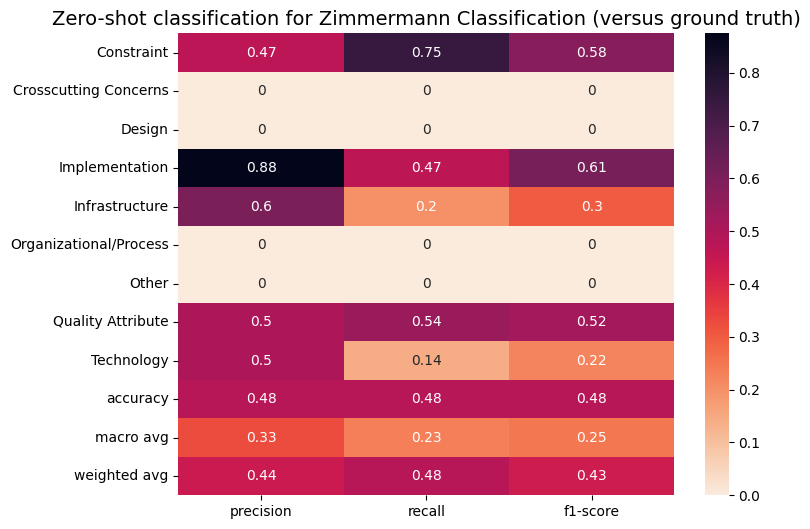

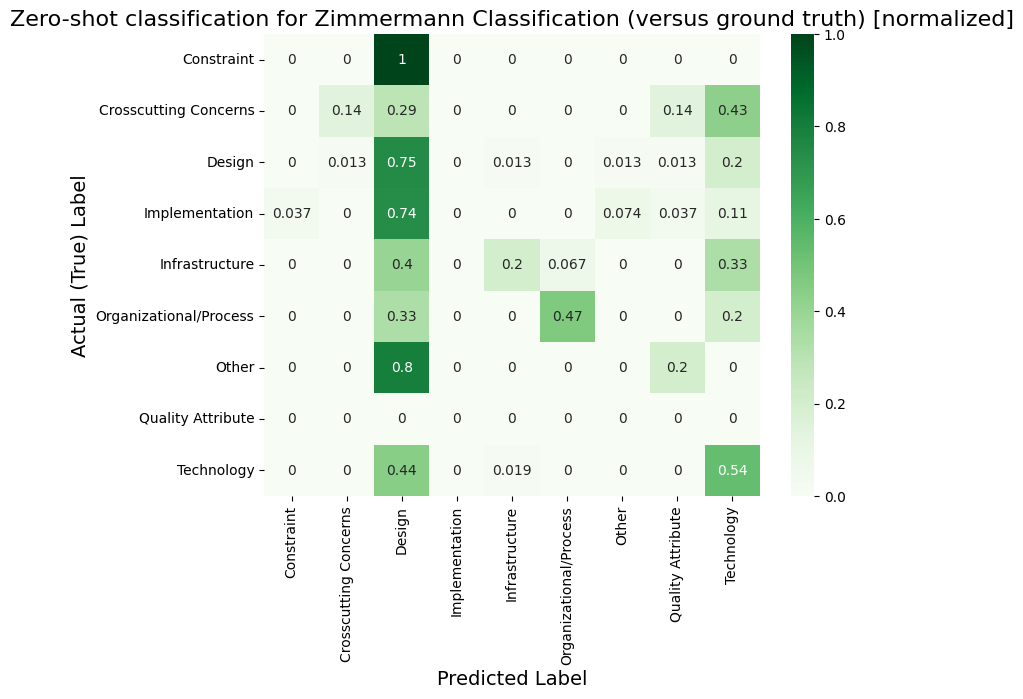

In [17]:
title = "Zero-shot classification for Zimmermann Classification (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

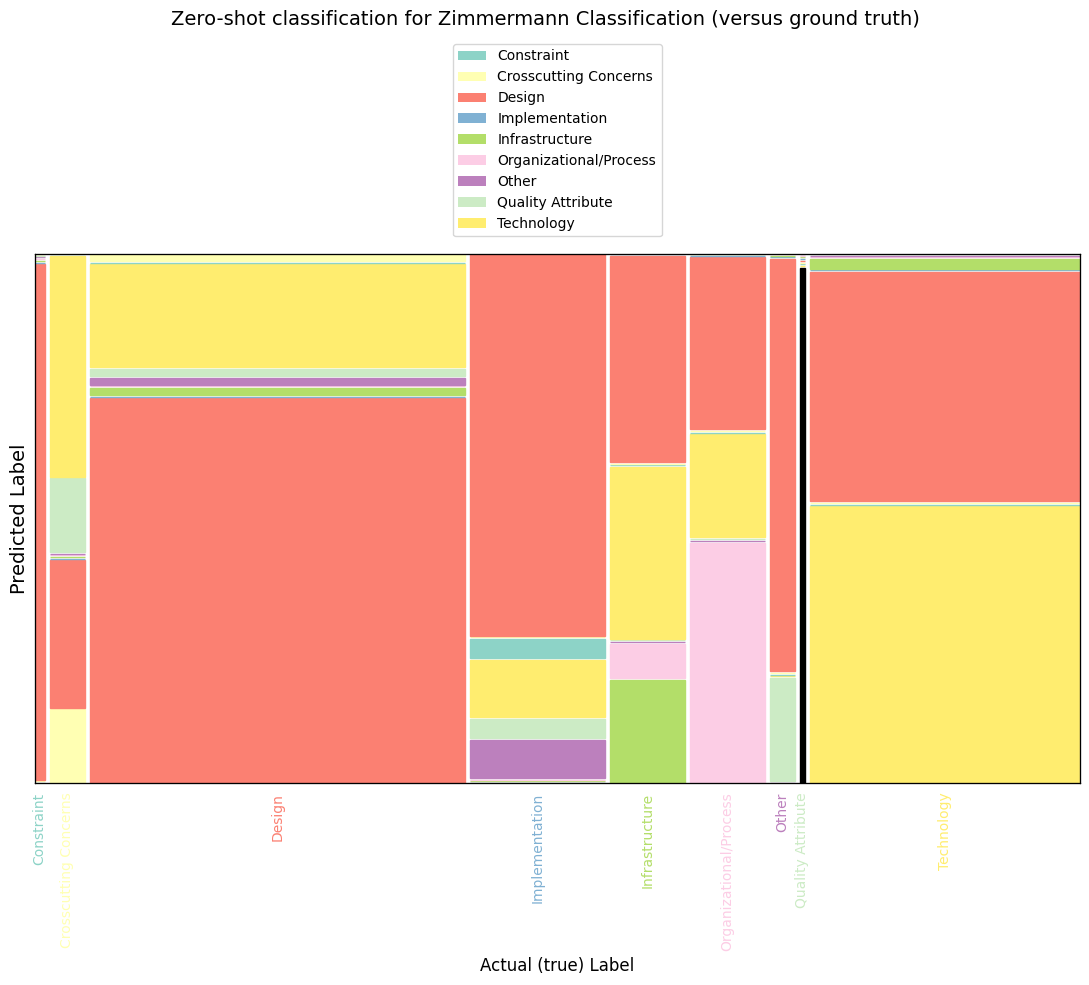

In [18]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
my_colors = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, title=title) #labels=output_dict['labels'])

In [19]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=9)

Differences with GT: 104


[(('Technology', 'Design'), 24),
 (('Implementation', 'Design'), 20),
 (('Design', 'Technology'), 15),
 (('Infrastructure', 'Design'), 6),
 (('Infrastructure', 'Technology'), 5),
 (('Organizational/Process', 'Design'), 5),
 (('Other', 'Design'), 4),
 (('Implementation', 'Technology'), 3),
 (('Crosscutting Concerns', 'Technology'), 3)]

In [20]:
# Filter specific cases of differences with GT
# true_categories = ['Other/Only Functional Concern', 'Maintainability']
# pred_categories = ['Other/Only Functional Concern', 'Maintainability']

# print(10*'--')
# for idx, cat_true, cat_pred, adr in output_dict['differences']:
#     if cat_true in true_categories and cat_pred in pred_categories:
#         print(cat_true, "vs.", cat_pred, "->", idx, adr)
#         print(10*'--')


#### Few-shot Strategy (static)

In [21]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.ZIMMERMANN, include_examples=True)

{"asctime": "2026-01-05 23:38:22,000", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: zimmermann, include_examples=True"}


In [22]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

System: Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one primary category. 
Use the category definitions, guidelines, rules and examples provided below.

## Categories:
- **Design**: This decision concerns the logical organization, structure, and decomposition of the system. It is related to patterns, components, layering, interfaces, data modeling.
  + e.g., "We apply the Model-View-Controller pattern for the UI."
  + e.g., "Services must be stateless to support scalability." (emphasis is more on stateless services than on scalability)
- **Technology**: This decision concerns the selection of technologies, platforms, frameworks, libraries, or standards.
  + e.g., "We use Kubernetes for container orchestration."
  + e.g., "The database must be PostgreSQL 14."
- **Infrastructure**: This decision involves the deployment environment, hosting, runtime platforms, networking, and hardware concerns.
  + e.g., "

In [23]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-05 23:38:22,059", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "zimmermann",
    "primary_category": "Design",
    "explanation": "The ADR primarily discusses the choice of creating a web application with offline capabilities, which pertains to the system's structure and how components are organized and interact. It focuses on the architectural pattern of a Progressive Web App (PWA) and its offline behavior, which are aspects of system design.",
    "primary_score": 0.85,
    "alternative_categories": [
        "Technology"
    ],
    "alternative_confidence_scores": [
        0.15
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)


In [24]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_static_few_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/zimmermann_gt_processed1_static_few_shot_results.json
Evaluating on ground truth with 200 ADRs.
Saving results to JSON file (for later processing) .././sample/zimmermann_gt_processed1_static_few_shot_results.json


In [25]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=9)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=9)

{"asctime": "2026-01-05 23:38:41,737", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}
{"asctime": "2026-01-05 23:38:41,737", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}
{"asctime": "2026-01-05 23:38:41,738", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [26]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Design', 'Implementation', 'Other', 'Organizational/Process', 'Infrastructure', 'Quality Attribute', 'Constraint', 'Technology', 'Crosscutting Concerns']

Matthews Coefficient: 0.29202217738903347
Similarities with GT (%): 48.5
Kappa agreement with GT: 0.28302937491298896


{'Constraint': -0.014492753623188248,
 'Crosscutting Concerns': 0.23822714681440438,
 'Design': 0.2736318407960199,
 'Implementation': -0.00973674720519302,
 'Infrastructure': 0.2934782608695652,
 'Organizational/Process': 0.516728624535316,
 'Other': -0.019108280254777066,
 'Quality Attribute': 0.0,
 'Technology': 0.38725490196078427}

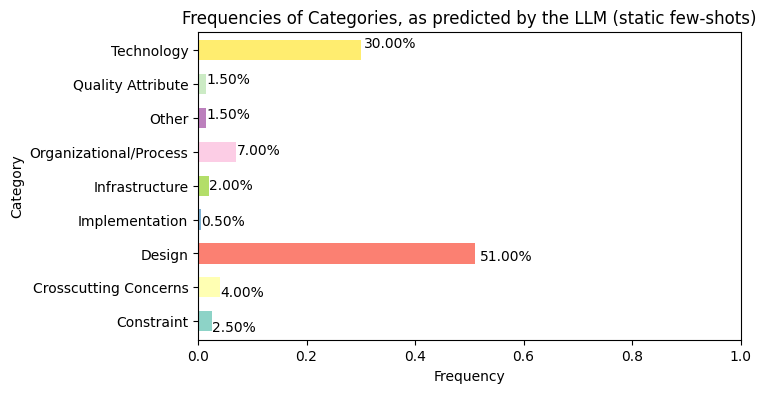

In [27]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (static few-shots)"
_ = utils.show_target_frequencies(pd.Series(target_values), color_dict=my_colors, title=title) #, encoding=encoding)
# Note that compatibility is missing in the LLM predictions

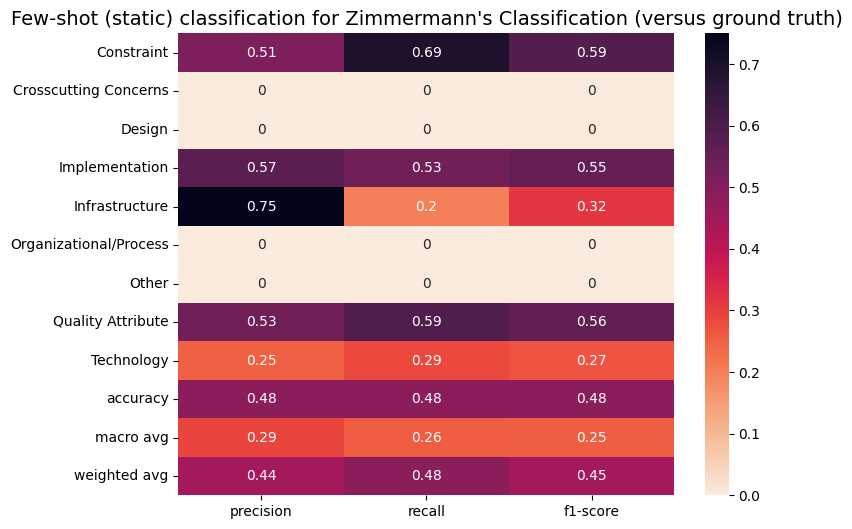

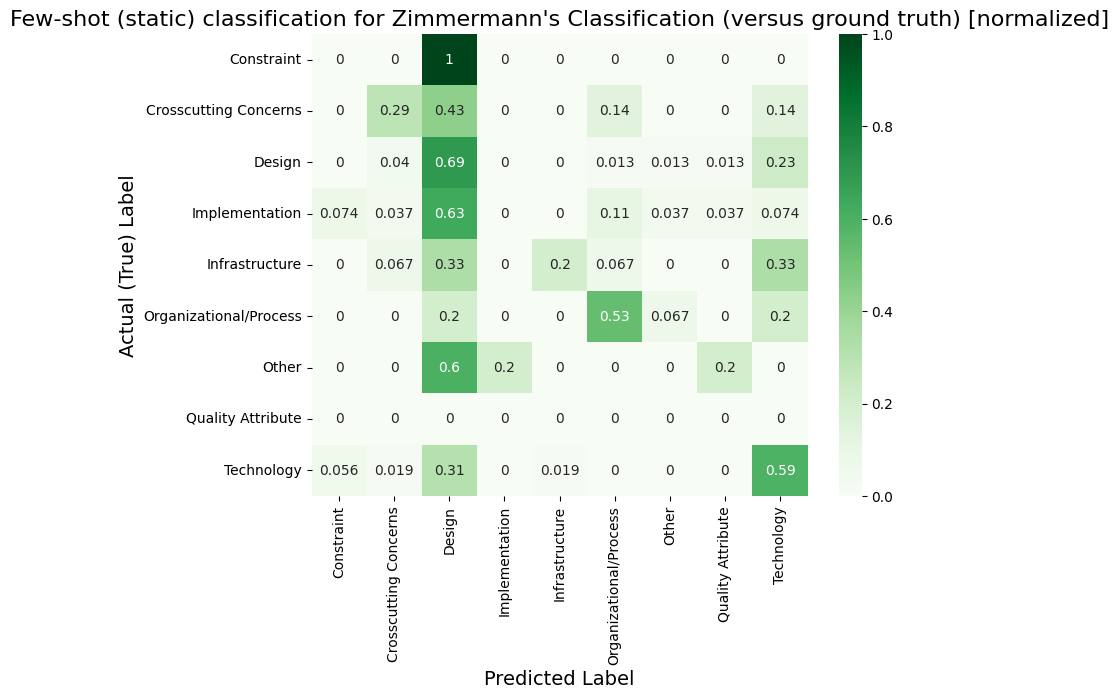

In [28]:
title = "Few-shot (static) classification for Zimmermann's Classification (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

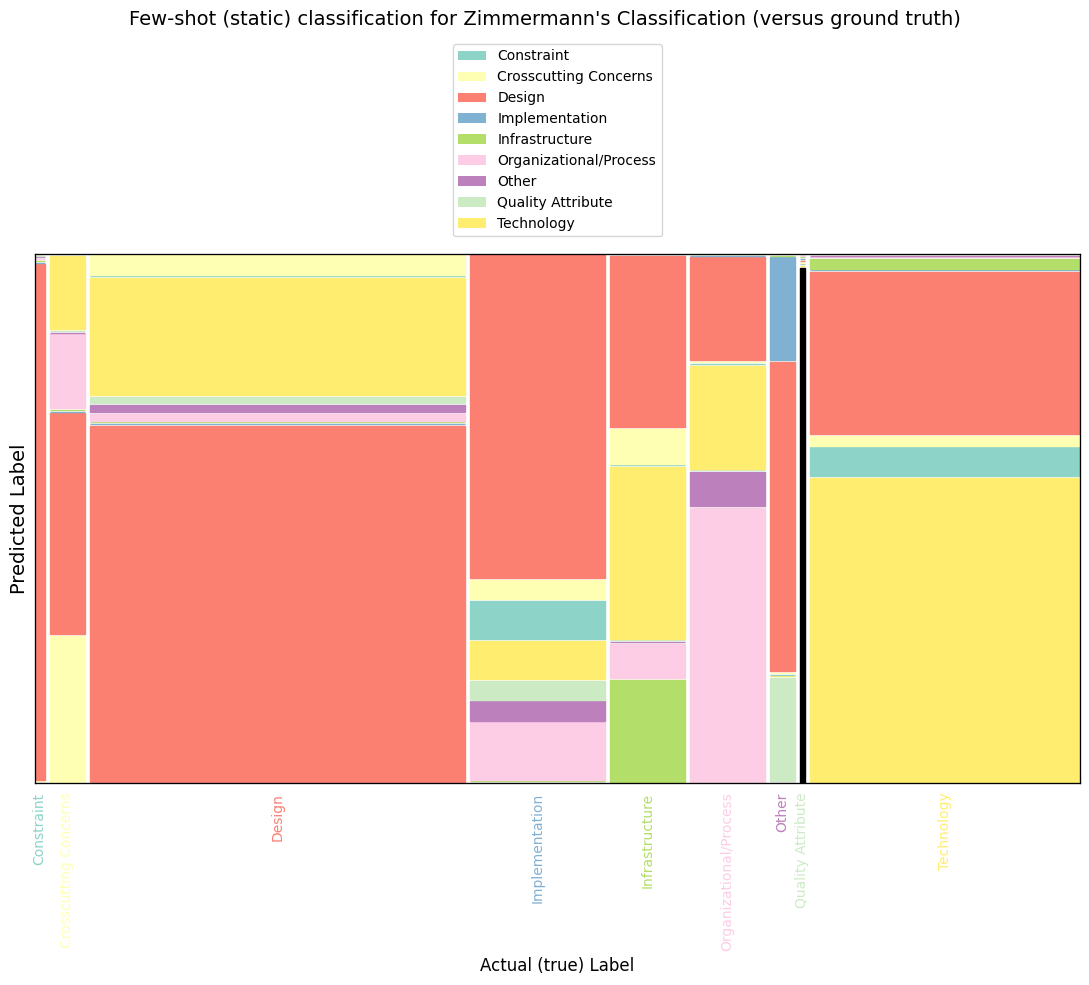

In [29]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, color_dict=my_colors, title=title) #labels=output_dict['labels'])

In [30]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=11)

Differences with GT: 103


[(('Technology', 'Design'), 17),
 (('Implementation', 'Design'), 17),
 (('Design', 'Technology'), 17),
 (('Infrastructure', 'Design'), 5),
 (('Infrastructure', 'Technology'), 5),
 (('Crosscutting Concerns', 'Design'), 3),
 (('Organizational/Process', 'Technology'), 3),
 (('Implementation', 'Organizational/Process'), 3),
 (('Organizational/Process', 'Design'), 3),
 (('Other', 'Design'), 3),
 (('Design', 'Crosscutting Concerns'), 3)]

#### Few-shot Strategy (dynamic)

In [31]:
with open(ZIMMERMANN_FEW_SHOTS, mode='r') as file:
        # The 'data' variable will be a Python list of dictionaries
        adr_examples = json.load(file)
# adr_examples

In [32]:
classifier = ADRClassifier(llm)
classifier.set_framework(ClassificationFramework.ZIMMERMANN, include_examples=True, examples=adr_examples, k=7)

{"asctime": "2026-01-05 23:38:42,558", "levelname": "INFO", "name": "adr_classification", "message": "Using classification framework: zimmermann, include_examples=True"}


In [33]:
# Inspect the classification prompt
print(classifier.classification_prompt.format(adr=adr_example))

Your are a senior software architect.
Your task is to analyze a given Architectural Decision Records (ADR) and classify it into one primary category. 
Use the category definitions, guidelines and rules provided below.

## Categories:
- **Design**: This decision concerns the logical organization, structure, and decomposition of the system. It is related to patterns, components, layering, interfaces, data modeling.
- **Technology**: This decision concerns the selection of technologies, platforms, frameworks, libraries, or standards.
- **Infrastructure**: This decision involves the deployment environment, hosting, runtime platforms, networking, and hardware concerns.
- **Organizational/Process**: This decision concerns team structures, roles, responsibilities, workflows, and processes that affect architecture.
- **Constraint**: It refers to mandatory conditions from the business, regulations, or existing systems that limit architectural choices.
- **Quality Attribute**: This decision expl

In [34]:
# Test classification on ADR example
result = classifier.classify(str(adr_example)) #, metadata={'organization': 'LBHackney-IT', 'project': 'remultiform'})
print(json.dumps(result, indent=4))

display(Markdown(adr_example))

{"asctime": "2026-01-05 23:38:53,954", "levelname": "INFO", "name": "adr_classification", "message": "Classifying ADR with 392 tokens."}
{
    "framework": "zimmermann",
    "primary_category": "Design",
    "explanation": "The ADR discusses the architectural organization of components and their interactions, specifically the connection between state, containers, and components, which pertains to system structure and component relationships.",
    "primary_score": 0.85,
    "alternative_categories": [
        "Crosscutting Concerns"
    ],
    "alternative_confidence_scores": [
        0.1
    ]
}


# Web Application

**Status:** Accepted

## Context

We need an application platform that meets the following requirements:

- Cross-platform: The app may be used to enter data on phone or tablet in real time or through a computer at a later stage.
- Works offline: Given the environmental conditions on a boat in the middle of the ocean, consistent internet connection is not a given. Thus, our tech stack must provide offline capabilities with minimal-to-no data loss.

### Option 1 - Cache First Web App (PWA)

By creating a web app that meets certain criteria, the app will be downloaded to cache on first use. This means that the app will be accessible offline. This option would also allow us to create a single application which could be used on any device with a modern web browser.

### Option 2 - Native application

Another option would be to develop a native application for each platform which may be used (iOS, macOS, Android, Windows). These apps could be developed more rapidly using something like React Native which would allow some components to be shared. This method would give us greater control and potentially give a better user experience.

## Decision

The decision was made to create a web app with offline capability due to the flexibility and speed it offers. Creating native applications for each of the required platforms would not be feasible with the available time and resources.

### PWA Issues

Since selecting a web app as the platform for this project a number of issues have been discovered:

- Updating the app to the latest version is inconsistent between browsers and devices.
- Refreshing while offline may show a 'No internet connection' page until the app is closed and reopened.
- Offline behaviour on iOS in particular seems inconsistent with other platforms.

## Links

- [Progessive Web Apps](https://web.dev/progressive-web-apps/)
- [Cache Invalidation Spike](https://github.com/BMMRO-tech/BMMRO/issues/43)


In [35]:
logging.getLogger('adr_classification').setLevel(level=logging.CRITICAL)

# Use batch classification for the ADRs in the ground truth
path = relative_path.replace('.csv', '_dynamic_few_shot_results.json')
print(path)
if not os.path.isfile(path):
    print(f"Evaluating on ground truth with {len(adr_texts)} ADRs.")
    # results = classifier.classify_batch(adrs_to_classify, as_dict=True, parallel=True, organization='LBHackney-IT', project='remultiform')
    results = classifier.classify_batch(adr_texts, as_dict=True, parallel=True)
    print("Saving results to JSON file (for later processing)", path)
    classifier.save_results(results, path)

logging.getLogger('adr_classification').setLevel(level=logging.INFO)
# results

.././sample/zimmermann_gt_processed1_dynamic_few_shot_results.json
Evaluating on ground truth with 200 ADRs.


ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': 'zindex-values.md'}
ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': 'adr-067-mempool-refactor.md'}
ERROR:root:Another parsing error occurred with fallback, skipping ADR: {'adr': '0002-use-bullet-to-catch-nplus1-queries.md'}


Saving results to JSON file (for later processing) .././sample/zimmermann_gt_processed1_dynamic_few_shot_results.json


In [36]:
# Load results for comparison of metrics with ground truth
with open(path, 'r') as file_handle:
    results = json.load(file_handle)
    
# output_dict = classifier.predict_and_evaluate_on_ground_truth(df_gt, max_labels=9)
output_dict = classifier.evaluate_on_ground_truth(df_gt, results, max_labels=9)

{"asctime": "2026-01-05 23:40:41,390", "levelname": "WARNING", "name": "adr_classification", "message": "Dropping 3 as they are not part of the LLM results. ['zindex-values.md', 'adr-067-mempool-refactor.md', '0002-use-bullet-to-catch-nplus1-queries.md']"}


{"asctime": "2026-01-05 23:40:41,391", "levelname": "WARNING", "name": "adr_classification", "message": "Predicted label 'Quality Attribute' not in ground truth labels."}


/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adiazpace/opt/anaconda3/envs/adrs/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [37]:
print(output_dict['labels'])
print()
print("Matthews Coefficient:", output_dict['matthews'])
print("Similarities with GT (%):", output_dict['similarities'])
print("Kappa agreement with GT:", output_dict['kappa'])
output_dict['kappa_scores']

['Design', 'Implementation', 'Other', 'Organizational/Process', 'Infrastructure', 'Quality Attribute', 'Constraint', 'Technology', 'Crosscutting Concerns']

Matthews Coefficient: 0.25107733837436835
Similarities with GT (%): 45.68527918781726
Kappa agreement with GT: 0.235104143987227


{'Constraint': -0.01025641025641022,
 'Crosscutting Concerns': 0.20974212034383954,
 'Design': 0.22979180920731102,
 'Implementation': 0.3117441547970976,
 'Infrastructure': 0.1401551891367604,
 'Organizational/Process': 0.21763304209690237,
 'Other': 0.5638376383763837,
 'Quality Attribute': 0.0,
 'Technology': 0.22538534130229626}

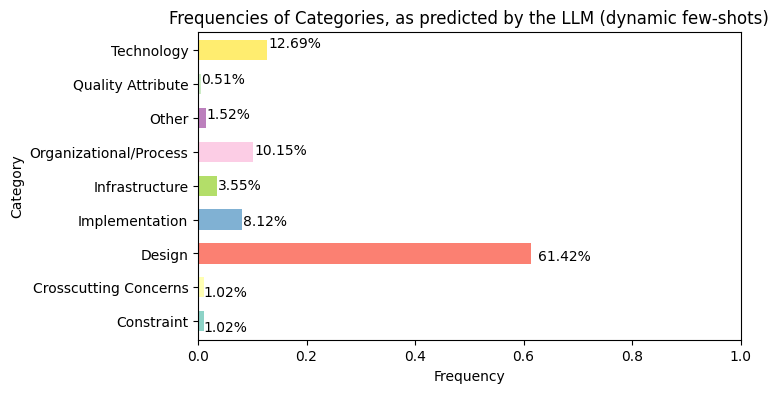

In [38]:
target_values = [x['primary_category'] for x in results]
# encoded_target = pd.Series(le.transform(target_values))

title = "Frequencies of Categories, as predicted by the LLM (dynamic few-shots)"
_ = utils.show_target_frequencies(pd.Series(target_values), color_dict=my_colors, title=title) #, encoding=encoding)
# Note: Compatibility is missing in the LLM predictions

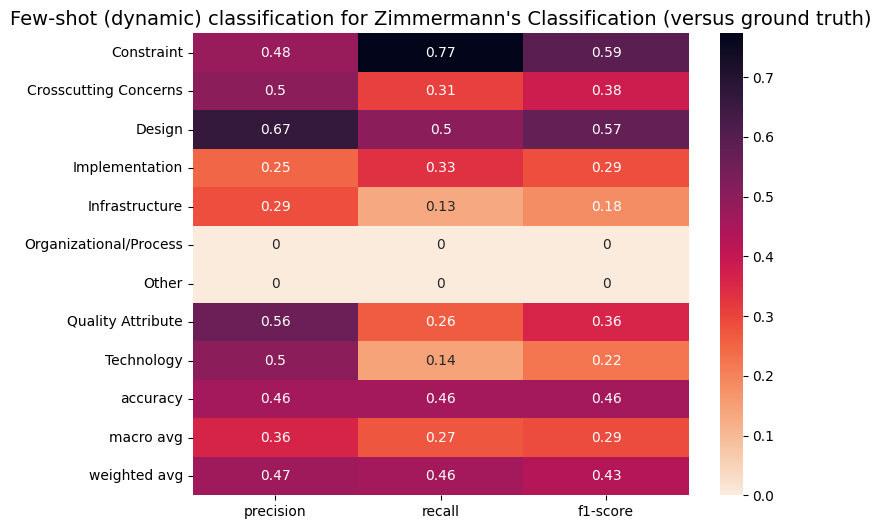

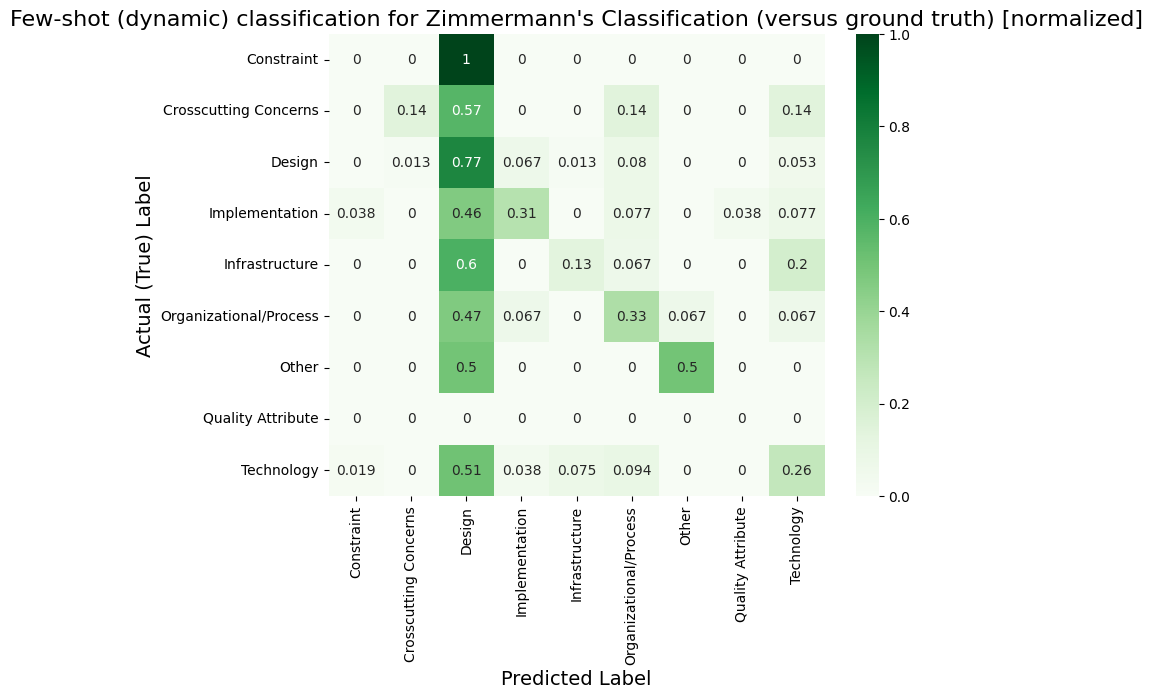

In [39]:
title = "Few-shot (dynamic) classification for Zimmermann's Classification (versus ground truth)"
utils.show_classification_report(output_dict['report'], title=title)
utils.show_confusion_matrix(output_dict['confusion_matrix'], title=title, normalized=True)

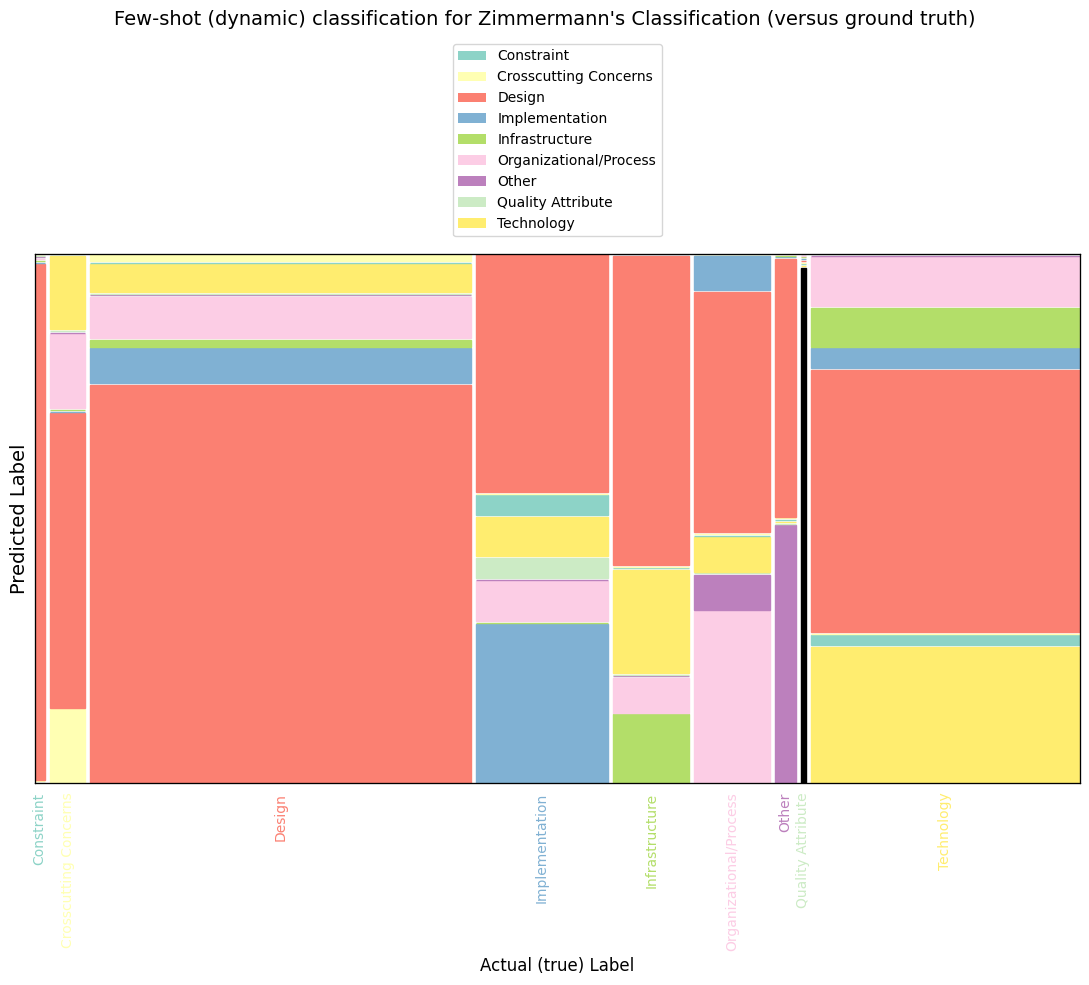

In [40]:
cm_labels = sorted(output_dict['confusion_matrix'].columns)
_ = utils.show_classification_mosaic(output_dict['confusion_matrix'].values, cm_labels=cm_labels, color_dict=my_colors, title=title) #labels=output_dict['labels'])

In [41]:
print("Differences with GT:", len(output_dict['differences']))
ADRClassifier.rank_differences(output_dict['differences'], n_categories=11)

Differences with GT: 107


[(('Technology', 'Design'), 27),
 (('Implementation', 'Design'), 12),
 (('Infrastructure', 'Design'), 9),
 (('Organizational/Process', 'Design'), 7),
 (('Design', 'Organizational/Process'), 6),
 (('Technology', 'Organizational/Process'), 5),
 (('Design', 'Implementation'), 5),
 (('Design', 'Technology'), 4),
 (('Technology', 'Infrastructure'), 4),
 (('Crosscutting Concerns', 'Design'), 4),
 (('Infrastructure', 'Technology'), 3)]

---

In [42]:
# TODO: Run the dynamic few-shots strategy on the FULL set of ADRs (there's no ground truth for all of them)